In [101]:
# !pip install pmdarima
# !pip install sktime[all_extras]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_absolute_error

from sktime.forecasting.arima import AutoARIMA
from sktime.forecasting.compose import (TransformedTargetForecaster, make_reduction)
from sktime.forecasting.model_selection import (ExpandingWindowSplitter, ForecastingGridSearchCV)
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
from sktime.utils.plotting import plot_series
from pmdarima import AutoARIMA


## Extracting Data and cleaning 
1.)First stage of cleaning involvesn removing null entries during maintainence of camera<br>
2.) Then removing the data between time stamp of 5-12<br>
3.) using regex for desired vehicle number so that ny digit blurring is ignored<br>
4.) Finally considering both entry and exit of vehicle<br>

In [102]:
df = pd.read_csv('parkingLot.csv', parse_dates=['timestamp'])

# Sort by timestamp to aid processing
df.sort_values(by='timestamp', inplace=True)

# Drop null entries logged during maintenance
df_cleaned = df.dropna(subset=['vehicle_no'])
df_cleaned = df_cleaned[(df_cleaned['timestamp'].dt.hour >= 5) & (df_cleaned['timestamp'].dt.hour < 24)]

#Remove those whose vehicle number is blurred
vehicle_pattern = r'^MH[A-Z]{2}\d{4}$'
df_cleaned = df_cleaned[df_cleaned['vehicle_no'].str.match(vehicle_pattern, na=False)]

#Extract entry and exit data 
df_entry = df_cleaned[df_cleaned['camera_id'] == 1]
df_exit = df_cleaned[df_cleaned['camera_id'] == 2]

#Consider only those vehicles that are in both entry and exit
df_entry = df_entry.drop_duplicates(subset='vehicle_no')
df_exit = df_exit.drop_duplicates(subset='vehicle_no')
common_vehicle_numbers = pd.Series(list(set(df_entry['vehicle_no']).intersection(set(df_exit['vehicle_no']))))
df_entry = df_entry[df_entry['vehicle_no'].isin(common_vehicle_numbers)]
df_exit = df_exit[df_exit['vehicle_no'].isin(common_vehicle_numbers)]

# daily count and avg time
daily_count = df_entry.groupby(df_entry['timestamp'].dt.date).size()
df_merged = pd.merge(df_entry, df_exit, on='vehicle_no', suffixes=('_in', '_out'))
df_merged['time_spent'] = (df_merged['timestamp_out'] - df_merged['timestamp_in']).dt.total_seconds() / 60
daily_avg_time = df_merged.groupby(df_merged['timestamp_in'].dt.date)['time_spent'].mean()


## Apply Moving Average Smoothing (7-day window)
Moving average smoothing helps reduce noise and reveal trends in your data over time. The 7-day rolling average smooths out daily fluctuations.

In [103]:
daily_count_MAS = daily_count.rolling(window=7, min_periods=1).mean()
daily_avg_time_MAS = daily_avg_time.rolling(window=7, min_periods=1).mean()

## Plotting the raw and cleaned data for comparision

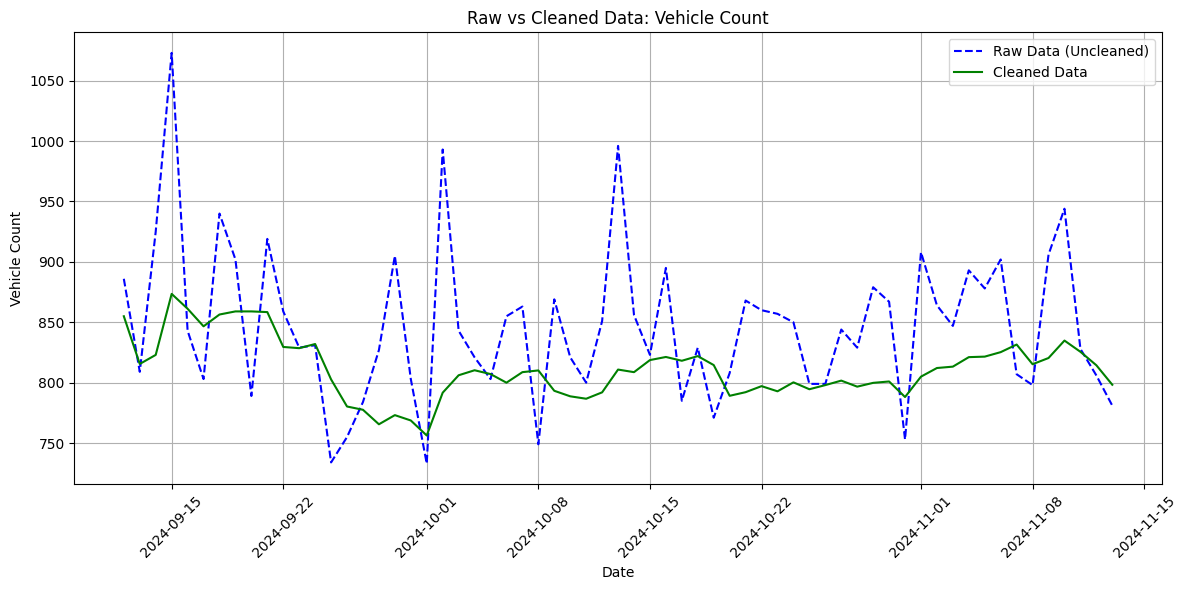

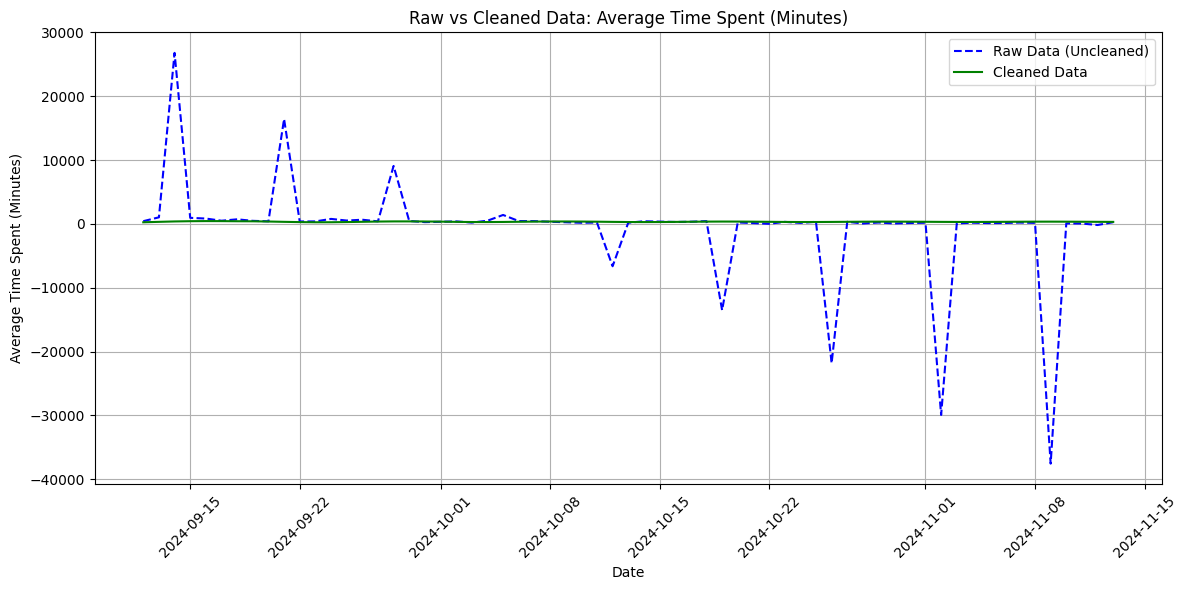

In [104]:
# Calculate daily count and average time for raw (uncleaned) data
df_entry_raw = df[df['camera_id'] == 1]
df_exit_raw = df[df['camera_id'] == 2]

# Raw daily vehicle count
daily_count_raw = df_entry_raw.groupby(df_entry_raw['timestamp'].dt.date).size()

# Merge raw entry and exit data to calculate average time
df_merged_raw = pd.merge(df_entry_raw, df_exit_raw, on='vehicle_no', suffixes=('_in', '_out'))
df_merged_raw['time_spent'] = (df_merged_raw['timestamp_out'] - df_merged_raw['timestamp_in']).dt.total_seconds() / 60
daily_avg_time_raw = df_merged_raw.groupby(df_merged_raw['timestamp_in'].dt.date)['time_spent'].mean()

# Plot: Data Before and After Cleaning for Vehicle Count
plt.figure(figsize=(12, 6))
plt.plot(daily_count_raw, label='Raw Data (Uncleaned)', color='blue', linestyle='--')
plt.plot(daily_count_MAS, label='Cleaned Data', color='green')
plt.title('Raw vs Cleaned Data: Vehicle Count')
plt.xlabel('Date')
plt.ylabel('Vehicle Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot: Data Before and After Cleaning for Average Time
plt.figure(figsize=(12, 6))
plt.plot(daily_avg_time_raw, label='Raw Data (Uncleaned)', color='blue', linestyle='--')
plt.plot(daily_avg_time_MAS, label='Cleaned Data', color='green')
plt.title('Raw vs Cleaned Data: Average Time Spent (Minutes)')
plt.xlabel('Date')
plt.ylabel('Average Time Spent (Minutes)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## Splitting into training and testing data
Test data for last 7 days and rest train

In [105]:
train_size = int(len(daily_count)-7)
train_count, test_count = daily_count_MAS[:train_size], daily_count_MAS[train_size:]
train_time, test_time = daily_avg_time_MAS[:train_size], daily_avg_time_MAS[train_size:]

## Plot for training , testing and forcasted data and finding MASE, MAPE

In [106]:
def plot_forecast(series_train, series_test, forecast,benchmark, forecast_int=None):

    mae_actual = mean_absolute_error(series_test, forecast)
    mae_naive=np.mean(np.abs(np.diff(benchmark)))
    MASE=mae_actual/mae_naive
    mape = MAPE(series_test, forecast)

    plt.figure(figsize=(12, 6))
    plt.title(f"MASE: {MASE:.2f}, MAPE: {mape*100:.3f}%, MAE: {mae_actual:.2f}", size=18)
    series_train.plot(label="train", color="b")
    series_test.plot(label="test", color="g")
    forecast.index = series_test.index
    forecast.plot(label="forecast", color="r",linestyle='--')
    if forecast_int is not None:
        plt.fill_between(
            series_test.index,
            forecast_int["lower"],
            forecast_int["upper"],
            alpha=0.2,
            color="dimgray",
        )
    plt.legend(prop={"size": 16})
    plt.show()

    return MASE, mape*100

## Using ARIMA model for forcasting the next 7 days vechicle count and average spent time

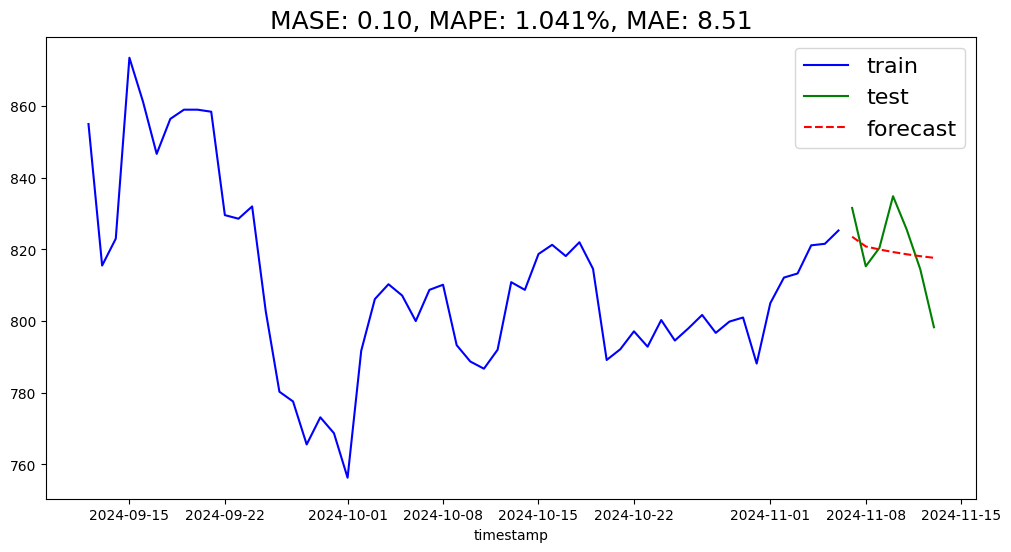

In [107]:
import warnings
warnings.filterwarnings("ignore")
forecaster = AutoARIMA( start_p=1, start_q=1, max_p=10, max_q=10, m=7, seasonal=False,suppress_warnings=True, stepwise=True)
forecaster.fit(train_count)
n_periods = 7
forecast_count = forecaster.predict(n_periods=n_periods)

# Optionally get confidence intervals if needed
forecast_count_int = forecaster.predict(n_periods=n_periods, return_conf_int=True)[1]
count_arima_mae, count_arima_mape = plot_forecast(
    train_count, test_count, forecast_count, forecast_count_int
)

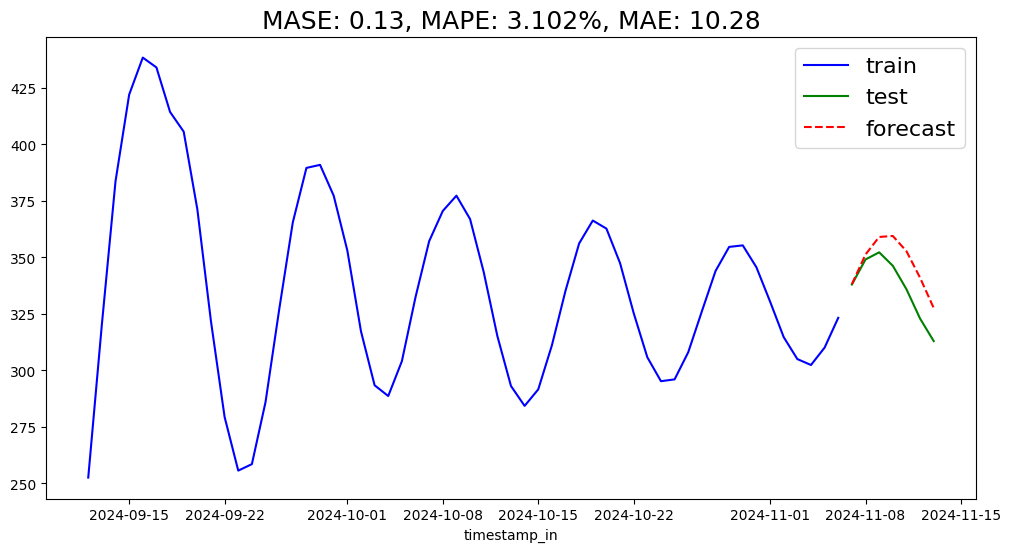

In [108]:
forecaster = AutoARIMA( start_p=1, start_q=1, max_p=10, max_q=10, m=7, seasonal=True,suppress_warnings=True, stepwise=True)
forecaster.fit(train_time)
n_periods = 7
forecast_time = forecaster.predict(n_periods=n_periods)

# Optionally get confidence intervals if needed
forecast_time_int = forecaster.predict(n_periods=n_periods, return_conf_int=True)[1]
count_arima_mae, count_arima_mape = plot_forecast(
    train_time, test_time, forecast_time, forecast_time_int
)

## Analysis
Moving average smoothing definitely improved forcasting for count but did worse for average time spent. Lets try another smoothing method for average time spent

## Using Exponential Moving average and InterQuartile range for average time 
The Moving average worked well for average count, however not so for average time spent due to being faster to recent changes

In [109]:
# Remove outliers using the IQR method
Q1 = df_merged['time_spent'].quantile(0.25)
Q3 = df_merged['time_spent'].quantile(0.75)
IQR = Q3 - Q1
df_merged = df_merged[(df_merged['time_spent'] >= Q1 - 1.5 * IQR) & (df_merged['time_spent'] <= Q3 + 1.5 * IQR)]
daily_avg_time = df_merged.groupby(df_merged['timestamp_in'].dt.date)['time_spent'].mean()

# Apply Exponential Moving Average (EMA) for daily average time spent
daily_avg_time_ewm = daily_avg_time.ewm(span=7, adjust=False).mean()

## Same process as above

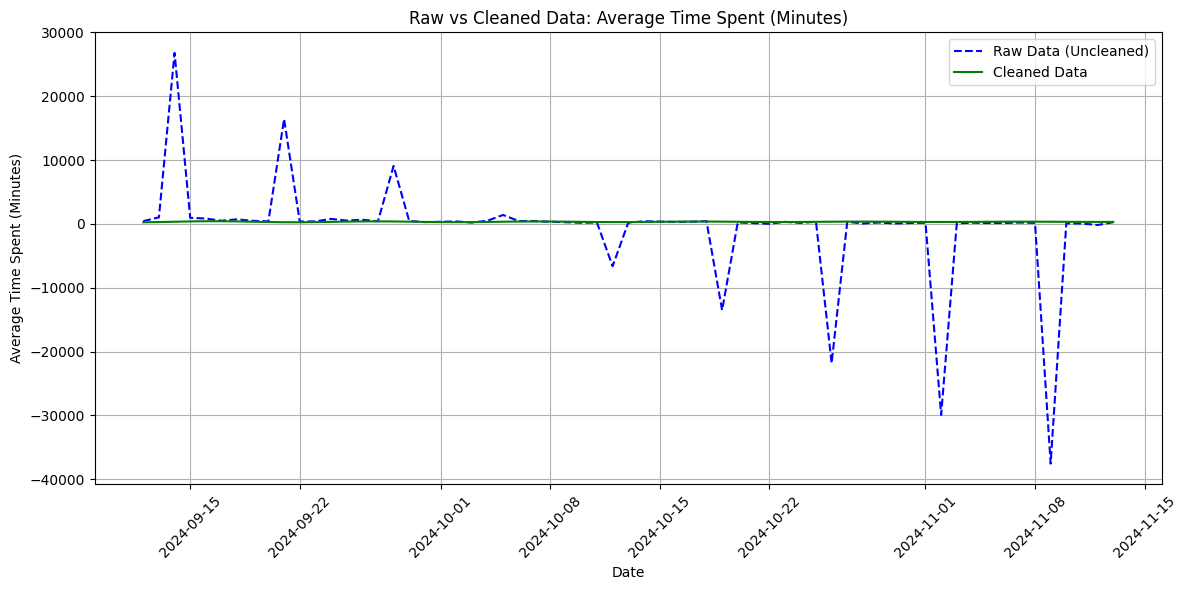

In [110]:
# Calculate average time for raw (uncleaned) data
df_entry_raw = df[df['camera_id'] == 1]
df_exit_raw = df[df['camera_id'] == 2]

# Merge raw entry and exit data to calculate average time
df_merged_raw = pd.merge(df_entry_raw, df_exit_raw, on='vehicle_no', suffixes=('_in', '_out'))
df_merged_raw['time_spent'] = (df_merged_raw['timestamp_out'] - df_merged_raw['timestamp_in']).dt.total_seconds() / 60
daily_avg_time_raw = df_merged_raw.groupby(df_merged_raw['timestamp_in'].dt.date)['time_spent'].mean()

# Plot: Data Before and After Cleaning for Average Time
plt.figure(figsize=(12, 6))
plt.plot(daily_avg_time_raw, label='Raw Data (Uncleaned)', color='blue', linestyle='--')
plt.plot(daily_avg_time_ewm, label='Cleaned Data', color='green')
plt.title('Raw vs Cleaned Data: Average Time Spent (Minutes)')
plt.xlabel('Date')
plt.ylabel('Average Time Spent (Minutes)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

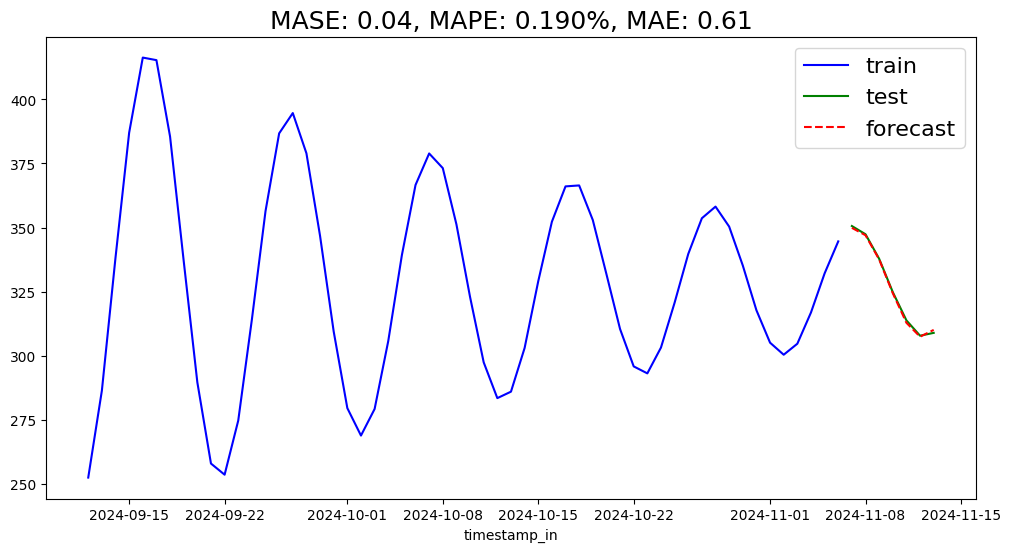

In [111]:
#test data for last 7 days and rest train
train_size = int(len(daily_avg_time_ewm)-7)
train_time, test_time = daily_avg_time_ewm[:train_size], daily_avg_time_ewm[train_size:]

forecaster = AutoARIMA( start_p=1, start_q=1, max_p=10, max_q=10, m=7, seasonal=True,suppress_warnings=True, stepwise=True)
forecaster.fit(train_time)
n_periods = 7
forecast_time = forecaster.predict(n_periods=n_periods)

# Optionally get confidence intervals if needed
forecast_time_int = forecaster.predict(n_periods=n_periods, return_conf_int=True)[1]
count_arima_mae, count_arima_mape = plot_forecast(
    train_time, test_time, forecast_time, forecast_time_int
)

## Analysis
This methods works well as it reduced MAPE from 0.613% to 0.190%. Now lets improve more using imputation methods

## Imputation using KNN and mean/median/mode
Based on filtering methods above, Moving average smoothing for daily count and exponential moving average for average time count has been taken into consideration

In [112]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

In [113]:
def knn_impute(df, feature_columns, n_neighbors=3):
    """Apply KNN imputation on the given DataFrame."""
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df_imputed = imputer.fit_transform(df[feature_columns])
    df[feature_columns] = df_imputed
    return df

In [114]:
# Load and preprocess data
df = pd.read_csv('parkingLot.csv', parse_dates=['timestamp'])
df.sort_values(by='timestamp', inplace=True)

# Drop null vehicle numbers but retain others for imputation
# Step 1: Drop entries with null vehicle_no but retain others for imputation
df_cleaned = df.dropna(subset=['vehicle_no'])

# Step 2: Encode vehicle_no for any categorical operations
vehicle_encoder = LabelEncoder()
df_cleaned['vehicle_no_encoded'] = vehicle_encoder.fit_transform(df_cleaned['vehicle_no'].astype(str))

# Step 3: Fill missing timestamps and camera_ids with forward fill or mean imputation
df_cleaned['timestamp'] = df_cleaned['timestamp'].fillna(method='ffill')
df_cleaned['camera_id'] = df_cleaned['camera_id'].fillna(df_cleaned['camera_id'].mode()[0])  # Mode for categorical

# Step 4: For any missing numeric values (like vehicle_no_encoded), use median imputation
df_cleaned['vehicle_no_encoded'] = df_cleaned['vehicle_no_encoded'].fillna(df_cleaned['vehicle_no_encoded'].median())

#Cleaning based on opening and closing time
df_cleaned = df_cleaned[(df_cleaned['timestamp'].dt.hour >= 5) & (df_cleaned['timestamp'].dt.hour < 24)]

# Keep only valid vehicle numbers using regex
vehicle_pattern = r'^MH[A-Z]{2}\d{4}$'
df_cleaned = df_cleaned[df_cleaned['vehicle_no'].str.match(vehicle_pattern, na=False)]
print(df_cleaned.isna().sum())
# Extract entry and exit data
df_entry = df_cleaned[df_cleaned['camera_id'] == 1]
df_exit = df_cleaned[df_cleaned['camera_id'] == 2]

# Advanced Imputation for Missing Entry/Exit Records

# Prepare data for KNN imputation
df_entry['day'] = df_entry['timestamp'].dt.dayofyear
df_exit['day'] = df_exit['timestamp'].dt.dayofyear

# 1. Use KNN Imputation to fill missing timestamps for entry/exit
df_entry = knn_impute(df_entry, ['day'])
df_exit = knn_impute(df_exit, ['day'])

# 2. Median-based imputation for impossible timestamps
df_entry['timestamp'] = df_entry['timestamp'].fillna(df_entry['timestamp'].median())
df_exit['timestamp'] = df_exit['timestamp'].fillna(df_exit['timestamp'].median())

# Ensure no duplicate vehicles remain
df_entry = df_entry.drop_duplicates(subset=['vehicle_no'])
df_exit = df_exit.drop_duplicates(subset=['vehicle_no'])

# Calculate common vehicles after imputation
common_vehicle_numbers = set(df_entry['vehicle_no']).intersection(set(df_exit['vehicle_no']))
df_entry = df_entry[df_entry['vehicle_no'].isin(common_vehicle_numbers)]
df_exit = df_exit[df_exit['vehicle_no'].isin(common_vehicle_numbers)]

# Compute Daily Count and Average Time
daily_count = df_entry.groupby(df_entry['timestamp'].dt.date).size()

# Merge entry and exit data for time calculation
df_merged = pd.merge(df_entry, df_exit, on='vehicle_no', suffixes=('_in', '_out'))
df_merged['time_spent'] = (df_merged['timestamp_out'] - df_merged['timestamp_in']).dt.total_seconds() / 60

# Daily average time spent
daily_avg_time = df_merged.groupby(df_merged['timestamp_in'].dt.date)['time_spent'].mean()

# Apply Smoothing

# 1. Smooth daily count with Moving Average
daily_count_MAS = daily_count.rolling(window=7, min_periods=1).mean()

# 2. Smooth daily average time with exponential moving average and IQR
Q1 = df_merged['time_spent'].quantile(0.25)
Q3 = df_merged['time_spent'].quantile(0.75)
IQR = Q3 - Q1
df_merged = df_merged[(df_merged['time_spent'] >= Q1 - 1.5 * IQR) & (df_merged['time_spent'] <= Q3 + 1.5 * IQR)]

# Apply Exponential Moving Average (EMA) for daily average time spent
daily_avg_time_ewm = daily_avg_time.ewm(span=7, adjust=False).mean()

vehicle_no            0
timestamp             0
camera_id             0
vehicle_no_encoded    0
dtype: int64


## Same process as above

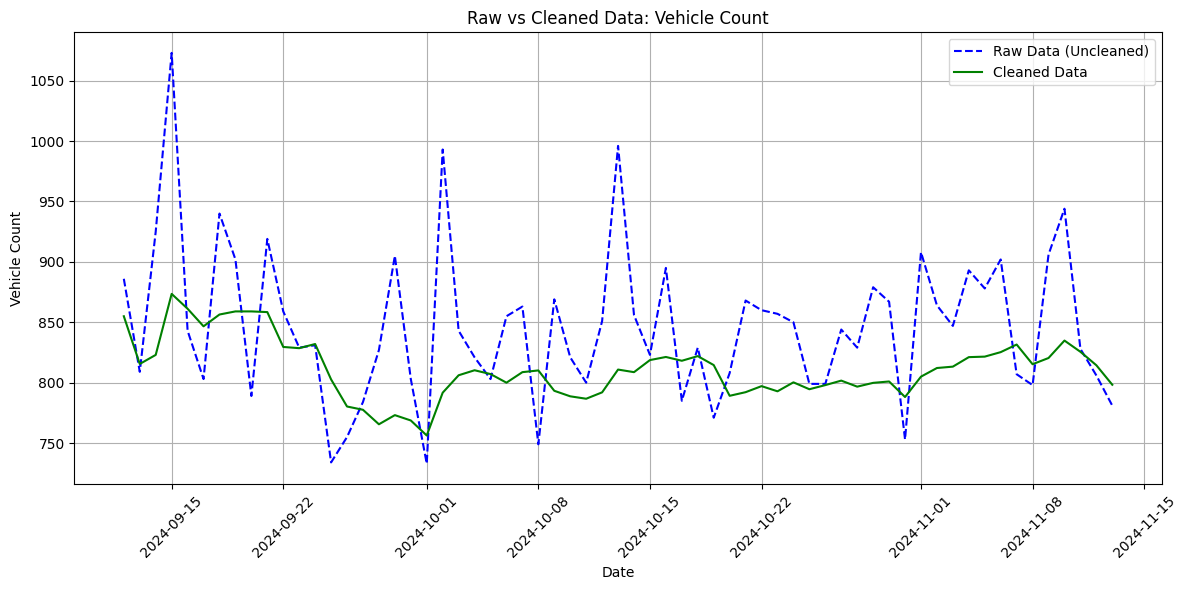

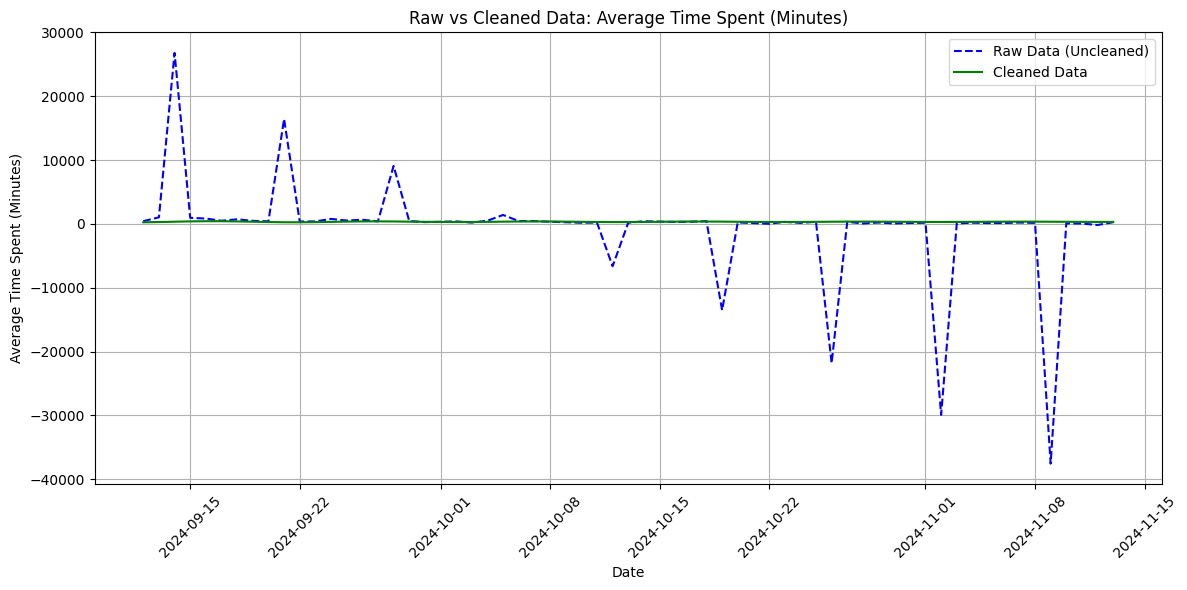

In [115]:
# Calculate daily count and average time for raw (uncleaned) data
df_entry_raw = df[df['camera_id'] == 1]
df_exit_raw = df[df['camera_id'] == 2]

# Raw daily vehicle count
daily_count_raw = df_entry_raw.groupby(df_entry_raw['timestamp'].dt.date).size()

# Merge raw entry and exit data to calculate average time
df_merged_raw = pd.merge(df_entry_raw, df_exit_raw, on='vehicle_no', suffixes=('_in', '_out'))
df_merged_raw['time_spent'] = (df_merged_raw['timestamp_out'] - df_merged_raw['timestamp_in']).dt.total_seconds() / 60
daily_avg_time_raw = df_merged_raw.groupby(df_merged_raw['timestamp_in'].dt.date)['time_spent'].mean()

# Plot: Data Before and After Cleaning for Vehicle Count
plt.figure(figsize=(12, 6))
plt.plot(daily_count_raw, label='Raw Data (Uncleaned)', color='blue', linestyle='--')
plt.plot(daily_count_MAS, label='Cleaned Data', color='green')
plt.title('Raw vs Cleaned Data: Vehicle Count')
plt.xlabel('Date')
plt.ylabel('Vehicle Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot: Data Before and After Cleaning for Average Time
plt.figure(figsize=(12, 6))
plt.plot(daily_avg_time_raw, label='Raw Data (Uncleaned)', color='blue', linestyle='--')
plt.plot(daily_avg_time_ewm, label='Cleaned Data', color='green')
plt.title('Raw vs Cleaned Data: Average Time Spent (Minutes)')
plt.xlabel('Date')
plt.ylabel('Average Time Spent (Minutes)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [116]:
#test data for last 7 days and rest train
train_size = int(len(daily_count)-7)
train_count, test_count = daily_count_MAS[:train_size], daily_count_MAS[train_size:]
train_time, test_time = daily_avg_time_ewm[:train_size], daily_avg_time_ewm[train_size:]

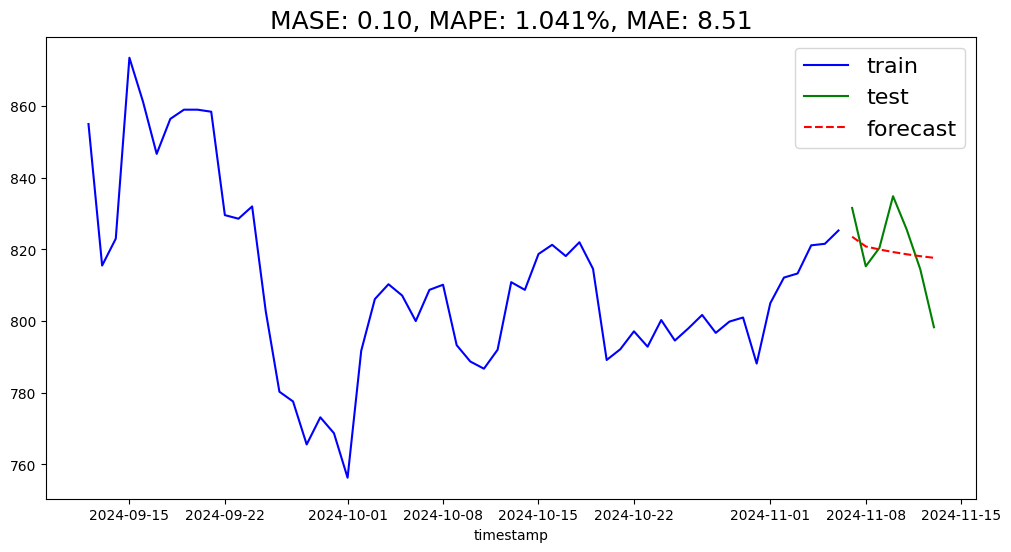

In [117]:
import warnings
warnings.filterwarnings("ignore")
forecaster = AutoARIMA( start_p=1, start_q=1, max_p=10, max_q=10, m=7, seasonal=False,suppress_warnings=True, stepwise=True)
forecaster.fit(train_count)
n_periods = 7
forecast_count = forecaster.predict(n_periods=n_periods)

# Optionally get confidence intervals if needed
forecast_count_int = forecaster.predict(n_periods=n_periods, return_conf_int=True)[1]
count_arima_mae, count_arima_mape = plot_forecast(
    train_count, test_count, forecast_count, forecast_count_int
)

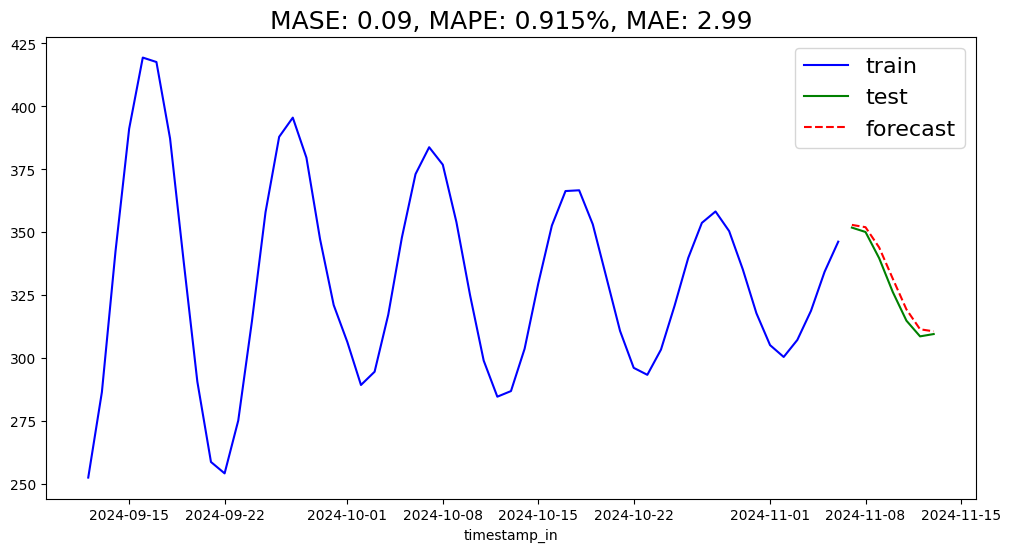

In [118]:
forecaster = AutoARIMA( start_p=1, start_q=1, max_p=10, max_q=10, m=7, seasonal=True,suppress_warnings=True, stepwise=True)
forecaster.fit(train_time)
n_periods = 7
forecast_time = forecaster.predict(n_periods=n_periods)

# Optionally get confidence intervals if needed
forecast_time_int = forecaster.predict(n_periods=n_periods, return_conf_int=True)[1]
count_arima_mae, count_arima_mape = plot_forecast(
    train_time, test_time, forecast_time, forecast_time_int
)

## Conclusion
Based on various smoothing methods, it turned out that Moving average smoothing and Exponential moving average smoothing turned out best for count and average time spent respectively.
Moreover after doing various imputation methods for filling missing data like mean/median/mode filling and K- Nearest Neighbour algorithm, same results are obtained as previous unlike the expectations. It maybe because the data may inherently lack variability or have few missing values that don't significantly affect the overall results.